# Homework 5: Numerical Optimization - Gradient Descent

## Due 9/30

Numerical Optimizations are very important. Much of machine learning is centered around optimizations as the primary tool for how we calibrate our machine learning models. Therefore, having a basic understanding of them is key if we hope to effectively train machine learning models in the future. In this homework we will cover some basic optimization techniques such as gradient descent and gradient descent with momentum.

In [1]:
!pip install jax

In [2]:
from functools import partial

import jax
import jax.numpy as np
import matplotlib.pyplot as plt

### Part 1: Gradient Descent

When we know the derivative of our function with respect to its inputs we can use gradient based optimizations. The simplest gradient based optimization is gradient descent. A good way to think about gradient descent is to imagine your placed randomly somewhere on a mountain, and your goal is to get down. A good strategy is to ask your self which way is down, walk that way for a bit, and every once in a while check to see if which way is down has changed at all, and if so, adjust your course till your at the bottom of the mountain.

Written out mathematically one step would look like this given an objective $J(x)$:

$x_{t+1} = x_t - \eta \cdot \nabla J(x_t)$

Where $\eta$ is a hyperparameter called learning rate (step size) that controls how big of a step we take down the mountain. If $\eta$ is small we change our current position $x$ just a little bit, and if it's big by a lot. The step size is really important as if its too small you waste all your time checking the gradient and never actually moving, if its too big you may miss the fact that the downward direction is changing and skip over the minimum. Hopefully this becomes more clear in the later examples.

In order to look at things more practically lets look at an example objective function.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Text(0, 0.5, 'Y')

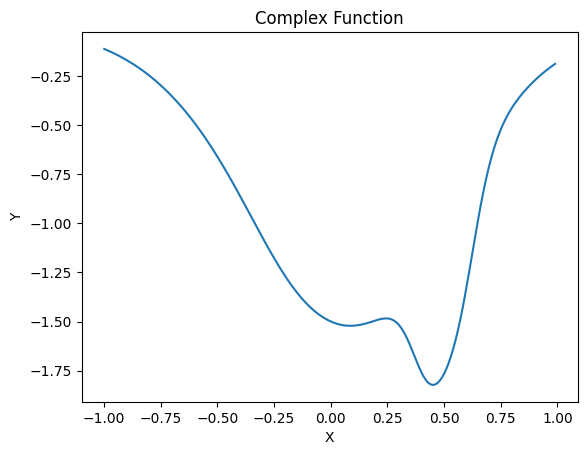

In [3]:
def complex_function_1D(x=None, parameters=None) -> int:
    y = 0
    for i in range(3):
        y += np.tanh(
            -1 * np.exp(-1 * (x - parameters[i]) ** 2 / parameters[i + 3])
        )  # Gaussian-like function
    return y


parameters = [0.1, 0.05, 0.5, 0.2, 0.5, 0.02]
x = np.arange(-1, 1, 0.01)
y = complex_function_1D(x=x, parameters=parameters)

plt.plot(x, y)
plt.title("Complex Function")
plt.xlabel("X")
plt.ylabel("Y")

Here we see we have a complicated function in 1d. The function takes in a value of x, and returns a value y. If we imagine this function to be an objective fuction we might also call y the loss, or cost to imply that we are trying to minimize it. This function also takes in a vector of parameters which controls its shape. Play around with these parameters to get a feel for what they do, but for now we will ignore them until part 2. Hopefully you'll notice that this function while 1d and fairly simple is actually really slippery and can represent a lot of different curves! This is an important observation for later.


You may have noticed that instead of importing numpy, we imported a different package at the start of this notebook - jax. Jax is a linear algebra + Automatic Differentiation(AD) package that can run on cpu or gpu (numpy doesn't support AD). The nice thing about jax is that it has a nearly identical interface to numpy, so you can just import jax.numpy as np, and mostly ignore the fact that your not actually using numpy. (note they do random numbers differently, so they can't always be substiuted blindly if your using stuff from np.random). We will use jax to take our derivatives for this assignment. The way this works is really simple. If we have a function called objective we just do grad_objective = jax.grad(objective), and now we have a new function that is the gradient of our original function. So if we want to evaluate gradient at some point x we can just call grad_objective(x) to compute that.

There is a little dance we will have to do to make this work for our complex function though. By default, `jax.grad()` computes the gradient with respect to the first argument of a function. Here, we use `partial` to fix the parameters so that `func` becomes a function of $x$ only. For part 1 we just want the gradient with respect to the variable we are trying to optimize - x. Because of this we don't really want to think about the parameters. Since the parameters are constant (won't change throughout the optimization) there is a neat trick we can use to ignore them. From the default python library functools there exists a function called partial. All it does is take a function and *some* of its inputs. It then returns a new function with those inputs always set. So the new function just looks like it takes the remaining inputs we didn't specify in partial. So in our case we have complex_function_1D which takes in x and parameters. if we do func = partial(complex_function_1D, parameters = parameters) we get a new function, func, which only takes in x, and uses the parameters we specified when calling partial. You'll see this in the next code cell where we do the partial function application as well as take the gradient.

In [4]:
parameters = [0.1, 0.05, 0.5, 0.2, 0.5, 0.02]
func = partial(complex_function_1D, parameters=parameters)
grad_func = jax.grad(func)

So now we have a function func which takes in only x, and the gradient of func, grad_func. Now all that needs to be done is to actually code gradient descent. Usually we encourage the use of packages in this class, but please write this function yourself. In addition to returning the final position of the minimum x0, the function should also log several things throughout each iteration. Firstly in the list *loc* append the current $x_0$ after each iteration, Additionally in the list *value* append the y value of func for the current value of $x_0$. In the same way log the gradient in the list *grads*.

The gradient_descent function will additionally need $\eta$ (learning rate/step_size), and the number of iterations it should run (n_iter).

A skeleton of the function has been provided below.

In [5]:
def gradient_descent(
    grad_func, func, x0, step_size: float = 0.001, n_iter: int = 100
) -> tuple[float, list[float], list[float], list[float]]:
    loc: list[float] = [x0]
    value: list[float] = [func(x0)]
    grads: list[float] = [grad_func(x0)]

    while n_iter > 0:
        n_iter -= 1
        x1 = x0 - step_size * grad_func(x0)
        x0 = x1  # update x

        loc.append(x1)
        value.append(func(x1))
        grads.append(grad_func(x1))

    return x0, loc, value, grads

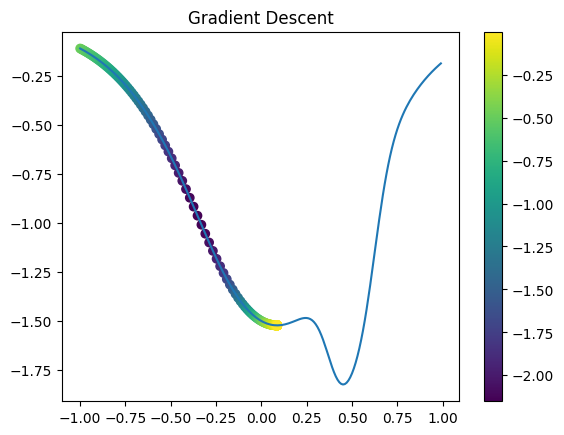

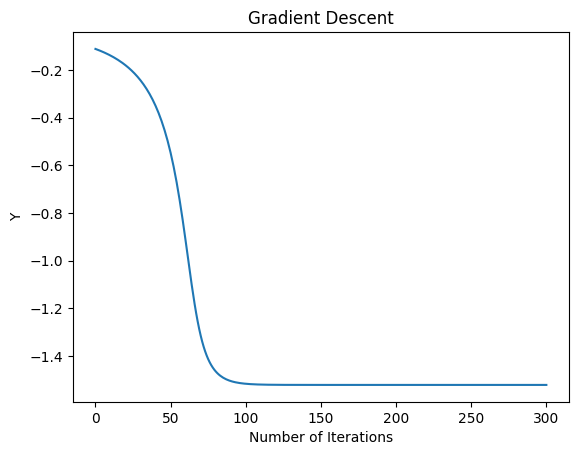

In [6]:
min_loc, loc, value, grads = gradient_descent(grad_func, func, x0=-1.0, step_size=0.01, n_iter=300)

x = np.arange(-1, 1, 0.01)
y = func(x)

plt.plot(x, y)
plt.title("Gradient Descent")
plt.scatter(loc, value, c=grads)
plt.colorbar()
plt.show()

plt.plot(value)
plt.title("Gradient Descent")
plt.xlabel("Number of Iterations")
plt.ylabel("Y")
plt.show()

If everything has gone correctly you will see two plots. The top shows this history of the gradient descent algorithm. Every dot on the curve corresponds to one spot where we stopped to revaluate our gradient before taking the next step, the color of the dot indicates the value of the gradient (which you can decode using the color bar on the right.)

The bottom plot is showing similar information but in a another way, Here we put the number of iterations on the x axis, and the value of y (the thing we want to minimize) on the Y axis. Here we can see how our optimization converges to a value on y as we take more steps.

There however is a glaring issue. We didn't find the minimum of the function. Since our function has multiple wells (known as local minimum) we got stuck in something that isnt actually the best minimum. Our algorithm saw that all directions were uphill and just stopped. This is a common issue with optimizations and most research using them is focused on how get around this issue. Here we will explore one simple modification that can help - momentum.

Momentum is a simple idea. In the first example we compared to gradient descent with deliberatly walking down a mountain. The addition of momentum is trying to make the process more like throwing a ball down a mountain. The key idea here is that the ball is retaining some kind of memory. For example if it's rolling down a steep hill it's going to be going fast, so if it runs into a small bump it will roll over it. The speed or momentum of the ball built up over prior steps is going to impact how it behaves in the future. We will use this idea to try to escape out of the local minimum we got stuck in last time. There are a wide variety of flavors of momentum but this simplest is to replace our gradient with a moving average of our gradient. In this way prior gradients influence futures ones. Mathematically one step would look like the following where $\beta$ is momentum:

$g_t = \nabla J(x_t)$

$m_t = (1-\beta) \cdot g_t + \beta \cdot m_{(t-1)}$

$x_{t+1} = x_t - \eta_t \cdot m_t$


Here $\beta$ is between 0 and 1 and m is momentum/moving average of gradients. All this is doing is just mixing the gradients together where $\beta$ is the percentage of the old gradient you want to keep. Since the old gradient is itself a mixture of older gradients you get the memory effect we were interested in from our ball example. The influence of older gradients decays exponentially due to repeated multiplication by $\beta$.

Initialize the momentum term as $(m_0=0)$. At each iteration, first compute the current gradient $(g_t=\nabla J(x_t))$, and then update the momentum using the current gradient and the accumulated gradient information from previous iterations.

In [7]:
def gradient_descent_momentum(
    grad_func, func, x0, step_size: float = 0.001, n_iter: int = 100, momentum: float = 0.9
) -> tuple[float, list[float], list[float], list[float]]:
    # Start lists with starting values
    loc: list[float] = [x0]
    value: list[float] = [func(x0)]
    m0 = 0
    momentums: list[float] = [m0]

    while n_iter > 0:
        n_iter -= 1

        # Perform gradient descent with momentum
        g1 = grad_func(x0)
        m1 = (1 - momentum) * g1 + momentum * m0
        x1 = x0 - step_size * m1
        x0 = x1  # update values
        m0 = m1

        loc.append(x1)
        value.append(func(x1))
        momentums.append(m1)

    return x0, loc, value, momentums

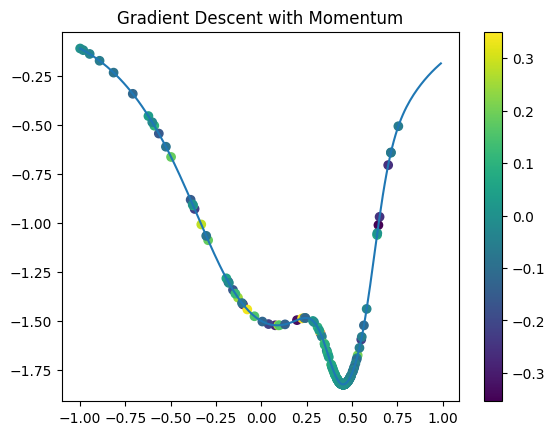

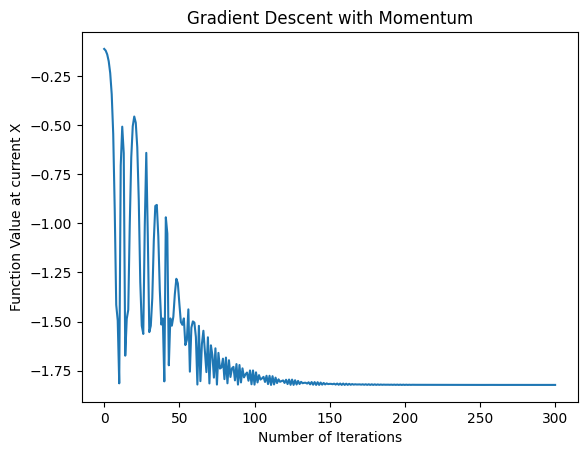

In [8]:
min_loc, loc, value, momentums = gradient_descent_momentum(
    grad_func, func, x0=-1.0, step_size=0.9, n_iter=300, momentum=0.96
)

x = np.arange(-1, 1, 0.01)
y = func(x)

plt.plot(x, y)
plt.title("Gradient Descent with Momentum")
plt.scatter(loc, value, c=momentums)
plt.colorbar()
plt.show()

plt.plot(value)
plt.title("Gradient Descent with Momentum")
plt.xlabel("Number of Iterations")
plt.ylabel("Function Value at current X")
plt.show()

And you can see with momentum in this example, momentum helps the optimizer move through the shallow local minimum and reach the lower minimum

### Part 2: Multi-Dimensional Optimization

This first example was fairly simple. We did an optimization on a 1d Function where we could see the minimum. Now it's time for something more complex, and more in line with how we do machine learning. In machine learning the goal is often to take a parameterized function, and learn what parameters best fit the data we observe. If we flip this problem around a little bit we can use the exact same function to try and learn the function parameters instead of the function minimum. In this way we will be doing a real machine learning task, given a parameterized function and data learn which parameters best fit the data.

In [9]:
# Generate Data
def complex_function_1D(parameters=None, x=None):
    y = 0
    for i in range(3):
        y += -1 * np.exp(
            -1 * (x - parameters[i]) ** 2 / parameters[i + 3]
        )  # Gaussian-like function
    return y


parameters = [0.1, 0.05, 0.5, 0.2, 0.5, 0.02]
x = np.arange(-1, 1, 0.05)
y = complex_function_1D(x=x, parameters=parameters)

Text(0, 0.5, 'Y')

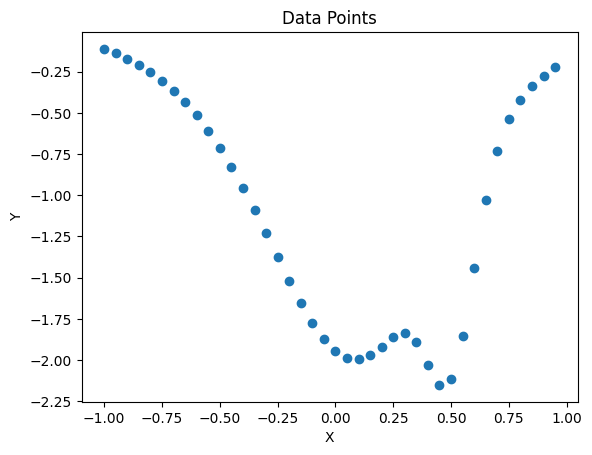

In [10]:
plt.scatter(x, y)
plt.title("Data Points")
plt.xlabel("X")
plt.ylabel("Y")

In this plot you now see a dataset of x,y positions. We made this using our handy function, so we do know which parameters were used to construct them, but for the sake of this problem lets assume that all we were given is the function, example points, and NO parameters. How can we use an optimization to recover which parameters produced the data?

The first step is to define an objective. The objective we will use here will be the mean squared error. Written out it would look like this:

$MSE = \frac{1}{N} \sum_{i=1}^{N} \left(f(x^i, parameters) - y^i\right)^2$

Where i is refering to the ith datapoint, and N is the total number of datapoints. This equation is simply asking what is the distance between my known value of y from the data, and the value predicted by the function f given initially some random parameters. We can think of the MSE as a function of these parameters $MSE(parameters)$ and take the gradient of the MSE with respect to the parameters, and find the minimum error. Looking at the equation above we can see that the minimum error will correspond to a set of parameters that best reproduces the known dataset. Exactly what we wanted.

We often call errors like the MSE a loss function, and we will use that term going forward.

Notice that we are using the partial function again but this time we are using it to set x. In this case the parameters are changing, and the data is staying constant.

In [11]:
func = partial(complex_function_1D, x=x)


def loss(parameters):
    return np.mean((y - func(parameters)) ** 2)


grad_loss = jax.grad(loss)

We already have all the code we need to perform this optimization (aka if your code crashes in the next section go back and fix it. It should work for both univariate and multivariate optimizations), below you can run the code to optimize the parameters.

You'll notice the optimization won't perform perfectly. Don't worry about it right now. Fixing it is part of the discussion questions.


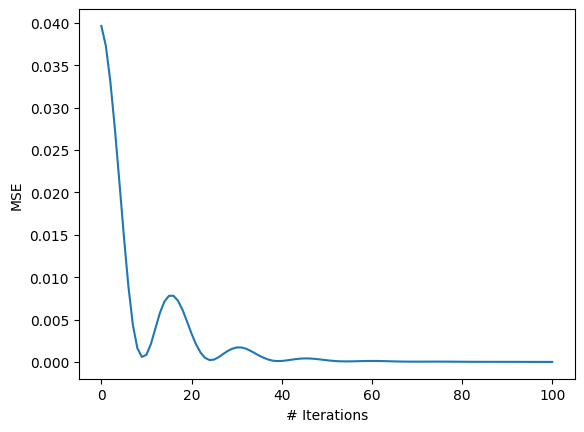

[0.06202269 0.4992632  0.09087018 0.5056855  0.02003914 0.1979173 ]


In [12]:
# Depending on the settings this can take a minute or so to run
min_loc, loc, value, momentums = gradient_descent_momentum(
    grad_loss,
    loss,
    x0=np.array([0.1, 0.4, 0.1, 0.5, 0.02, 0.2]),
    step_size=0.05,
    n_iter=100,
    momentum=0.9,
)

plt.plot(value)
plt.xlabel("# Iterations")
plt.ylabel("MSE")
plt.show()

print(min_loc)

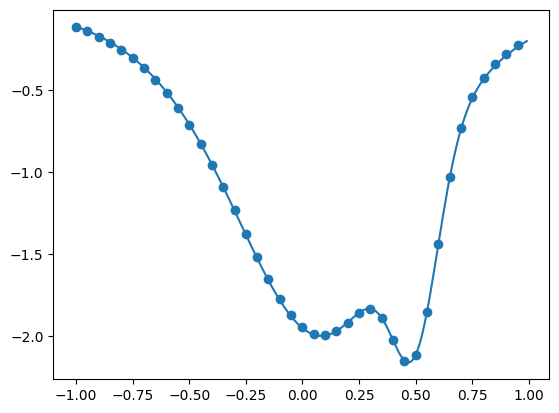

In [13]:
x_p = np.arange(-1, 1, 0.01)
y_p = complex_function_1D(x=x_p, parameters=min_loc)

plt.scatter(x, y)
plt.plot(x_p, y_p)

### Part 3: Discussion

Question 1: Look at the loss/function value plots. What do they tell us about the optimization? Why do these plots flat line? Why do we see oscillations when using momentum?

Question 2: Play around with different step sizes, momentums (between 0 and 1), and number of iterations and answer the following questions (use the univariate optimization for this).

1) What happens if we make the step size very large (>1). Does our optimization still converge? If not why?

2) What happens if we use more or less iterations? Why?

3) Clearly step size and momentum have a big impact on the final output of the optimization. How might we go about selecting the right values for these parameters?

Question 3: For the multivariate optimization identify a set of hyperparameters (step sizes, momentums, and # iterations) that gets a good fit of the function (don't change the initial point). Answer the following questions.

1) Explain your rationale to why you chose the hyperparameters you did, and what procedure you used to find them.

2) Look at the final parameters that you got. Do they match the original parameters? If not how is that possible?





# Answers

## Q1.
The loss / function plots tell us that the optimization worked. They show how the objective changes as the optimizer updates its position. 
When gradient descent works, the value decreases rapidly and then more slowly as it approaches a minimum. The fact they flat line means that the optimization converged to a value. 
The gradient of a minimum is 0, so as we approach it, the gradient value decreases asymptotically to 0. 
Now, as seen by the normal gradient descent, that value may not be the true global minimum of the function. 
We see oscillations when using momentum because of momentum itself. 
It is the moving average of previous gradients, and so when a change in direction happens (from +tive to -tive gradient), 
it still takes a few more steps / iterations to completely change the direction of the average. 
When the optimizer reaches a minimum, the accumulated momentum continues pushing it past it. The gradient then changes direction and pulls it back. 
The oscillations usually become smaller and smaller as the opposing gradients and decay reduce the accumulated momentum.

## Q2.
### 1.
Increasing the step size, especially greater than 1, makes the optimization generally not converge, as it is always overshooting. 
Each update can jump over the minimum instead of approach it. The optimizer oscillates with increasing magnitude, move into a different part of the function, 
or diverge entirely (the case for the ones above). This is since the gradient is multiplied by the step size, and so even if the gradient points in the right 
direction, multiplying it by a very large number moves the optimizer too far.

### 2.
Using more iterations generally provides more opportunities for the solution to move toward and settle near a minimum, but, at this point, will have no effect, 
as the solutions already converged to a number in the above optimizations. So no matter the amount of extra iterations, the gradients and parameters are already close to zero, 
so that value will not change significantly - it will also not fix getting stuck in a local minimum. If we use less iterations, though, that can make the optimization be cut short 
and not actually converge to a number - that would happen at anything below around 25 steps for the optimization just above. So the number must be large enough for convergence, 
but increasing it indefinitely gives us diminishing returns and wastes computation.

### 3.
There's no way to know the correct step size and iterations without experimentation. But good values can be found with a simple sweep:

1. Start relatively small step size.
2. Run the optimization while looking at the loss
3. Increase step size until convergence becomes fast but remains stable
4. Try several momentum values between 0 and 1.
5. Increase the iteration count until additional iterations don't meaningfully reduce the loss.
6. Compare the final losses and loss curves for every combination

Doing a sweep / grid search / random search could make this process fast / automated. For real machine learning, the hyperparameters are 
normally selected using validation data instead of judging the training loss. Learning rate schedules could also reduce the step size as the optimization approaches a minimum.

## Q3.
### 1.
I chose the set of hyperparameters to be:

```
step_size = 0.05
momentum = 0.9
n_iter = 100
```

These produce a very small final loss and very close parameters to the actual ones (though they are not in the same order).

I selected them by first increasing the step size and comparing the loss. You could see it was a straight line before (and spanned very small range), 
so it was clear a greater step size was necessary. A momentum of 0.9 smoothed the gradient updates and helped maintain progress. And then, from first choosing 1000 iterations, 
it was clear by the loss curve that the solution converged at around 100 iterations - so I then changed `n_iter` to 100.

### 2.
Just as mentioned above, the original parameters were:

`[0.10, 0.05, 0.50, 0.20, 0.50, 0.02]`

The first three values are the centers of the three components, and the last three values are their corresponding widths. So, actually, the original center width pairs were:

```
(0.10, 0.20)
(0.05, 0.50)
(0.50, 0.02)
```

Now, organizing the obtained parameters in the same way, we get approximately:

```
(0.05, 0.50)
(0.50, 0.02)
(0.10, 0.20)
```

These are the exact three components but just in a different order. Since the function adds the components together, changing their order doesn't change the output. 
Multiple parameter vectors can represent the same function. THe optimizer just found an equivalent solution even though its parameter vector doesn't exactly match the original ordering.


### Part 4: Polynomial Regression

While using optimizations is nice, I hope you've come to appreciate how finicky they can be (selecting hyperparameters, missing minima, etc.), and the reality is that they can be overkill for simple problems like this. Lets try to redo part 2 but this time using a more direct approach like polynomial regression. The goal is to show that if you can get away with it, simpler techniques can give you a lot more confidence that you've done your modeling correctly while still being good enough. Naturally these simpler techniques won't always work, and in those cases optimizations will always be there when we need them.

In [14]:
# Generate Data
def complex_function_1D(parameters=None, x=None):
    y = 0
    for i in range(3):
        y += -1 * np.exp(-1 * (x - parameters[i]) ** 2 / parameters[i + 3])
    return y


parameters = [0.1, 0.05, 0.5, 0.2, 0.5, 0.02]
x = np.arange(-1, 1, 0.05)
y = complex_function_1D(x=x, parameters=parameters)

Here is a simple example of polynomial regression using sklearn. More info here: https://scikit-learn.org/stable/modules/linear_model.html#polynomial-regression-extending-linear-models-with-basis-functions.

Initially the degree of the polynomial will be set to 1 (Linear Regression). As part of the discussion please change this around.

R² Score: 0.9995496273040771


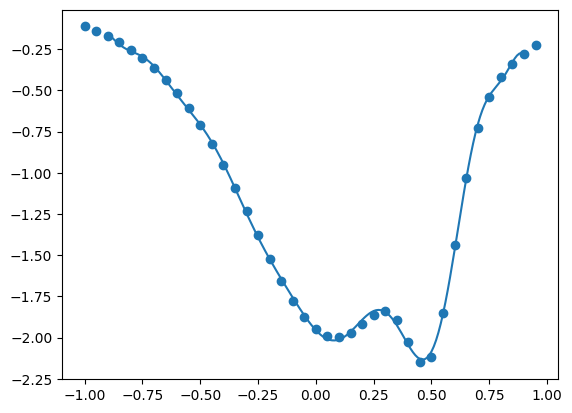

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

model = Pipeline([("poly", PolynomialFeatures(degree=16)), ("linear", LinearRegression())])

model.fit(x.reshape(-1, 1), y.reshape(-1, 1))

x_p = np.arange(-0.9, 0.9, 0.01)
y_p = model.predict(x_p.reshape(-1, 1))

plt.scatter(x, y)
plt.plot(x_p, y_p)

print(f"R² Score: {model.score(x.reshape(-1, 1), y.reshape(-1, 1))}")

### Part 5: Discussion

Question 4: Polynomial regression is a simpler modeling approach. One important hyperparameter is the degree of the polynomial. Try different polynomial degrees. What do you notice at lower and higher degrees? At what degree does the model begin to fit the data well?

Question 5: What is the $R^2$ value? How does it change as the polynomial degree changes?

Question 6: Should we be concerned about using high order polynomials when modeling the data. Why or why not?

# Answers

## Q4.
At low degrees, the model underfits the data. A linear model, for example, can't represent the multiple curves and narrow minimum the dataset has.
Increasing the degree gives the polynomial enough flexibility to follow the non-linear shapes. Increasing the degree of the polynomial too much, though, 
the curve still remains closely fitting the points, but the polynomial can develop unecessary curvature and osciallations at places, especially near the boundaries 
and between the data points. This is actually also the root of overfitting - high order polynomials may fit the noise.
The model begins to fit the data well at around degree 10 - $R^2$ greater than 0.99. But only really visually fit the curve super well at around degree 15 or 16, with their 
$R^2$ values being around 0.9995.

## Q5.
The $R^2$ value measures how much of the variation in the observed output is explained by the model. The equation is:

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y_i})^2}{\sum (y_i - \bar{y})^2}
$$

So, a value of 1 represents a perfect fit - the numerator, the change between the prediction and the actual values, is 0. A value of 0 means that the model is no better than always 
predicting the mean of the observed values. A negative value means it is worse than that.

Here, we see $R^2$ increase with increasing polynomial degree. This occurs because, like stated above, higher order polynomials are able to better represent the non-linearities of 
the dataset.

## Q6.
Yes, we definitely should. Like said before, high-degree polynomials may fit the training observations very well while fitting noise or small details that don't actually represent 
the underlying relationship of the parameters and outputs. This is literally what overfitting is. High order polynomials can also oscillate strongly between data points, behave unpredictably 
around boundaries, extrapolate very badly outside of the training range, produce very large coefficients, and become unstable numerically as polynomial features can be very correlated.

In this assignment, the dataset has no noise and is generated from a known function, so high order polynomials do very well on the training data. But real measurements always contain noise and 
make overfitting a real concern. We generally want to select the lowest order polynomial that still gives a good enough approximation of the data, and never just use the training's $R^2$ as 
the score, looking at validation data as well, for example.